#🛢️ Crude Oil Price Analysis & Forecasting (1970-2026)
### Notebook 03 - Time Series Forecasting: ARIMA, Prophet, LSTM

**What this notebook covers:**
1. Quick-start and train/test split
2. Model A: Auto-ARIMA with walk-forward validation
3. Model B: Facebook Prophet with custom changepoints
4. Model C: LSTM deep learning with sliding window features
5. Model comparison: RMSE, MAE, MAPE on the same test set
6. 12-month forward forecast from all three models
7. Save all models, forecasts, and evaluation results to Drive

> **Prerequisite:** Run notebooks 00 and 01 first. Notebook 02 is recommended but optional.

---

## 0 - Quick-Start Block

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, warnings, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

# Install missing library
!pip install pmdarima

# Stats / forecasting
import pmdarima as pm
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

PROJECT_ROOT = '/content/drive/MyDrive/crude_oil_project'
PATHS = {
    'root':      PROJECT_ROOT,
    'data':      os.path.join(PROJECT_ROOT, 'data'),
    'models':    os.path.join(PROJECT_ROOT, 'models'),
    'figures':   os.path.join(PROJECT_ROOT, 'outputs', 'figures'),
    'forecasts': os.path.join(PROJECT_ROOT, 'outputs', 'forecasts'),
}

df = pd.read_csv(
    os.path.join(PATHS['data'], 'oil_clean.csv'),
    index_col='Date', parse_dates=True
)
df.index = pd.DatetimeIndex(df.index, freq='MS')

C_BLUE   = '#3266AD'
C_RED    = '#E8593C'
C_AMBER  = '#D4930A'
C_TEAL   = '#1D9E75'
C_PURPLE = '#7F77DD'
C_GRAY   = '#888780'
FIGSIZE  = (14, 5)

tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'Dataset    : {len(df)} rows  ({df.index.min().date()} to {df.index.max().date()})')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 17.0 MB/s eta 0:00:00
TensorFlow : 2.19.0
Dataset    : 675 rows  (1970-01-01 to 2026-03-01)


---
## 1 - Train / Test Split

We use the last **24 months** as the held-out test set.  
All three models are trained on identical data and evaluated on the identical test window,
so the comparison is fair.

The series up to the split date is used for training; nothing after is seen during model fitting.

Train: 651 months  (1970-01-01 to 2024-03-01)
Test : 24  months  (2024-04-01  to 2026-03-01)
Forecast horizon: 12 months ahead of 2026-03-01


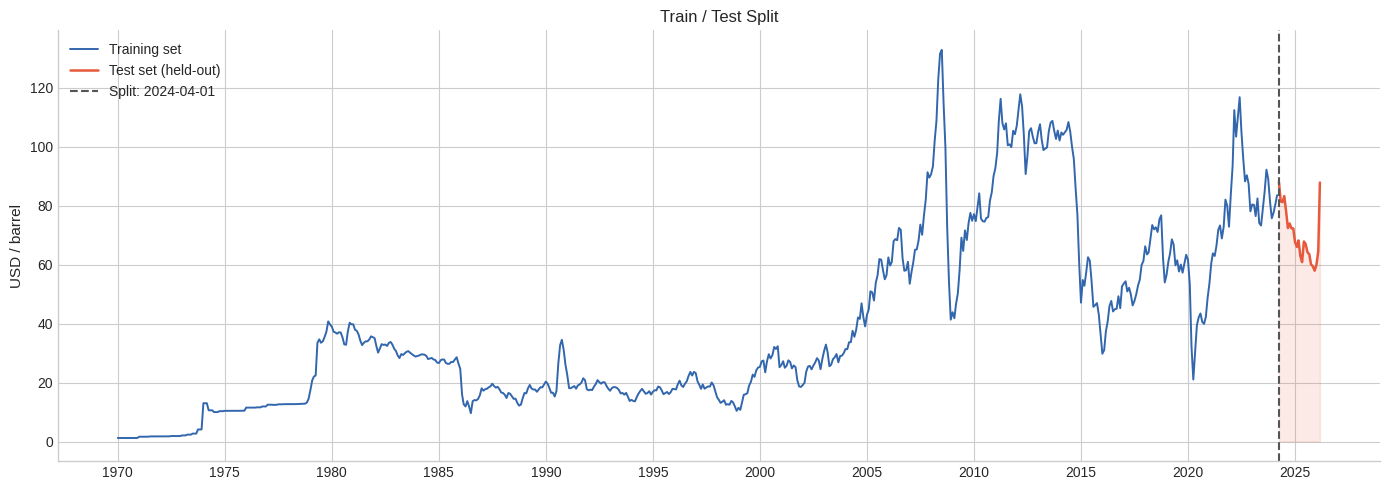

In [3]:
TEST_MONTHS    = 24    # hold-out window length
FORECAST_MONTHS = 12  # forward forecast horizon

series = df['price'].copy()

train = series.iloc[:-TEST_MONTHS]
test  = series.iloc[-TEST_MONTHS:]

split_date = test.index[0]

print(f'Train: {len(train)} months  ({train.index.min().date()} to {train.index.max().date()})')
print(f'Test : {len(test)}  months  ({test.index.min().date()}  to {test.index.max().date()})')
print(f'Forecast horizon: {FORECAST_MONTHS} months ahead of {test.index.max().date()}')

# Quick visualisation of the split
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(train.index, train.values, color=C_BLUE, lw=1.4, label='Training set')
ax.plot(test.index,  test.values,  color=C_RED,  lw=1.8, label='Test set (held-out)')
ax.axvline(split_date, color='#555', lw=1.5, ls='--', label=f'Split: {split_date.date()}')
ax.fill_between(test.index, test.values, alpha=0.12, color=C_RED)
ax.set_ylabel('USD / barrel', fontsize=11)
ax.set_title('Train / Test Split', fontsize=12, fontweight='medium')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '03_train_test_split.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Evaluation Helper Functions

Defined once, reused by all three models.

In [4]:
def mape(actual, predicted):
    """Mean Absolute Percentage Error - ignores zeros."""
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def evaluate(actual, predicted, model_name):
    """Print and return a dict of evaluation metrics."""
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape_val = mape(actual, predicted)
    print(f'  {model_name}')
    print(f'    RMSE : {rmse:.4f}')
    print(f'    MAE  : {mae:.4f}')
    print(f'    MAPE : {mape_val:.2f}%')
    print()
    return {'model': model_name, 'RMSE': round(rmse, 4),
            'MAE': round(mae, 4), 'MAPE': round(mape_val, 2)}

def plot_forecast(ax, train, test, pred, ci_lower=None, ci_upper=None,
                  color=C_BLUE, title=''):
    """Standard forecast plot panel used across all three models."""
    ax.plot(train.index[-36:], train.values[-36:],
            color=C_GRAY, lw=1.3, alpha=0.7, label='Training (last 36m)')
    ax.plot(test.index, test.values,
            color='black', lw=2.0, alpha=0.85, label='Actual (test)')
    ax.plot(test.index, pred,
            color=color, lw=2.0, ls='--', label='Forecast')
    if ci_lower is not None and ci_upper is not None:
        ax.fill_between(test.index, ci_lower, ci_upper,
                        alpha=0.15, color=color, label='95% CI')
    ax.axvline(test.index[0], color='#aaa', lw=1, ls=':')
    ax.set_title(title, fontsize=11, fontweight='medium')
    ax.set_ylabel('USD / barrel', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.legend(fontsize=8)

all_metrics = []   # collects dicts from evaluate() for final comparison
all_preds   = {}   # stores {model_name: Series of test-period predictions}
all_futures = {}   # stores {model_name: Series of 12-month forward forecasts}
print('Helper functions ready.')

Helper functions ready.


---
## 2 - Model A: Auto-ARIMA

### Why ARIMA first?
ARIMA is the **statistical benchmark**.  Every time series forecasting project should start here
because it is interpretable, fast to train, and often hard to beat on short horizons.
If a complex deep learning model cannot outperform ARIMA, something is wrong with the setup.

### Walk-forward (expanding window) validation
Instead of a single train/test split, walk-forward validation re-trains the model at each
step, appending the previous actual value before predicting the next. This is the correct
way to evaluate a time-series model because it mimics real deployment conditions.

In [5]:
print('Fitting Auto-ARIMA on training set...')
print('(This runs stepwise search - expect ~60-120 seconds)')
print()

arima_model = pm.auto_arima(
    train,
    start_p=0, max_p=4,
    start_q=0, max_q=4,
    d=None,                 # auto-detect differencing order via KPSS test
    seasonal=True,
    m=12,                   # monthly seasonality
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=None,
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True              # prints candidate models and AIC scores
)

print()
print('Best model selected:', arima_model.order, 'x', arima_model.seasonal_order)
print(arima_model.summary())

Fitting Auto-ARIMA on training set...
(This runs stepwise search - expect ~60-120 seconds)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3636.206, Time=0.10 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3549.039, Time=0.41 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3556.748, Time=0.41 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3634.872, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=3547.175, Time=0.08 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=3549.006, Time=0.27 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=3549.900, Time=0.57 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=3548.039, Time=0.12 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=3548.364, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=3554.757, Time=0.11 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=3539.921, Time=0.49 sec
 ARIMA(2,1,1)(1,0,0)[12] intercept   : AIC=3541.392, Time=1.28 sec
 ARIMA(2,1,1)(0,0,1)[12] intercept   : AIC=3541.264, Time=1.2

In [6]:
print('Running walk-forward validation on test set...')
print(f'  Predicting {TEST_MONTHS} months one step at a time (re-fitting each step)...')

# Clone the fitted model; update() appends one observation at a time
wf_model = arima_model
arima_preds = []
arima_ci_lo = []
arima_ci_hi = []

history = train.copy()

for i, (date, actual_val) in enumerate(test.items()):
    fc, conf = wf_model.predict(n_periods=1, return_conf_int=True, alpha=0.05)
    arima_preds.append(float(fc[0]))
    arima_ci_lo.append(float(conf[0][0]))
    arima_ci_hi.append(float(conf[0][1]))
    # Append actual observation and update model
    wf_model.update([actual_val])
    if (i + 1) % 6 == 0:
        print(f'    Step {i+1:2d}/{TEST_MONTHS}  {date.date()}  '
              f'pred={arima_preds[-1]:.2f}  actual={actual_val:.2f}')

arima_preds  = np.array(arima_preds)
arima_ci_lo  = np.array(arima_ci_lo)
arima_ci_hi  = np.array(arima_ci_hi)

print()
m = evaluate(test.values, arima_preds, 'ARIMA (walk-forward)')
all_metrics.append(m)
all_preds['ARIMA'] = pd.Series(arima_preds, index=test.index)

Running walk-forward validation on test set...
  Predicting 24 months one step at a time (re-fitting each step)...
    Step  6/24  2024-09-01  pred=76.21  actual=72.42
    Step 12/24  2025-03-01  pred=65.89  actual=68.20
    Step 18/24  2025-09-01  pred=63.53  actual=63.51
    Step 24/24  2026-03-01  pred=66.43  actual=87.84

  ARIMA (walk-forward)
    RMSE : 5.7498
    MAE  : 3.8816
    MAPE : 5.28%



Fitting final ARIMA on full series (train + test) for forward forecast...


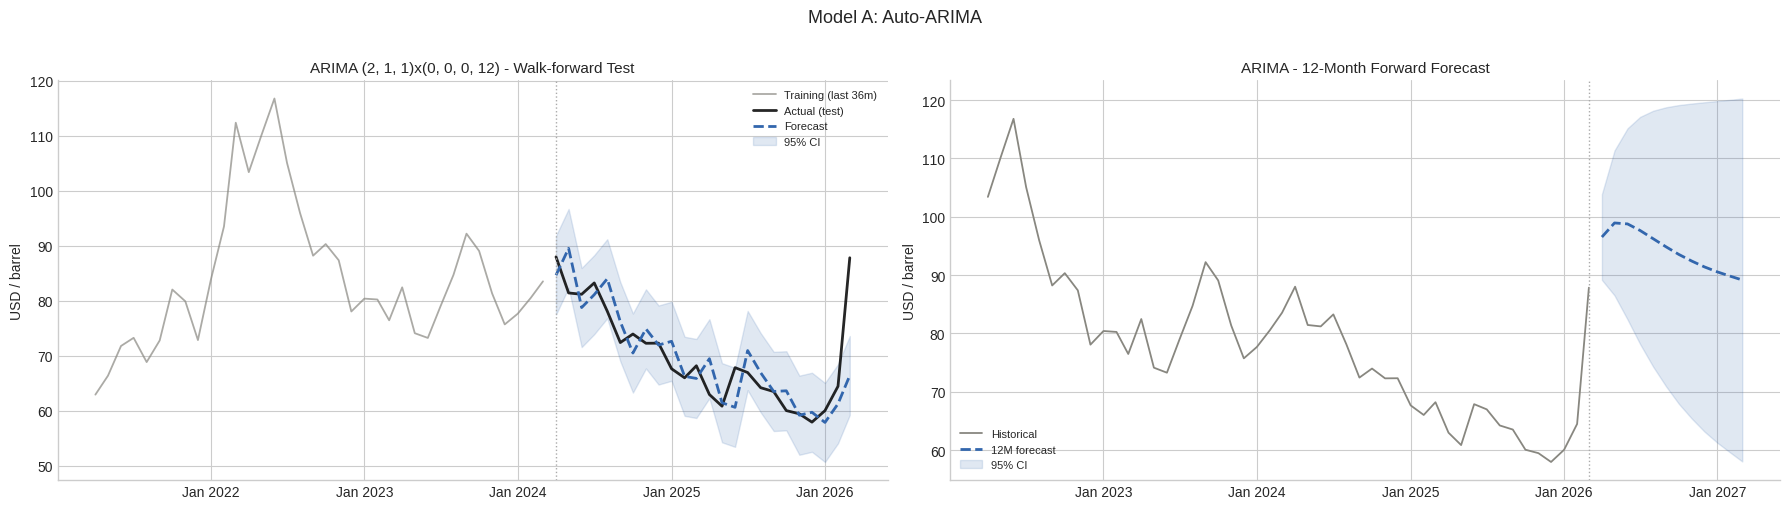

ARIMA model saved.


In [7]:
# Fit final ARIMA on full series for the forward forecast
print('Fitting final ARIMA on full series (train + test) for forward forecast...')

final_arima = pm.auto_arima(
    series,
    start_p=arima_model.order[0], max_p=arima_model.order[0] + 1,
    start_q=arima_model.order[2], max_q=arima_model.order[2] + 1,
    d=arima_model.order[1],
    seasonal=True, m=12,
    start_P=arima_model.seasonal_order[0],
    start_Q=arima_model.seasonal_order[2],
    D=arima_model.seasonal_order[1],
    stepwise=True, suppress_warnings=True, error_action='ignore'
)

fc_future, ci_future = final_arima.predict(
    n_periods=FORECAST_MONTHS, return_conf_int=True, alpha=0.05
)

future_dates = pd.date_range(
    start=series.index[-1] + pd.DateOffset(months=1),
    periods=FORECAST_MONTHS, freq='MS'
)
arima_future = pd.Series(fc_future, index=future_dates)
arima_future_lo = pd.Series(ci_future[:, 0], index=future_dates)
arima_future_hi = pd.Series(ci_future[:, 1], index=future_dates)
all_futures['ARIMA'] = arima_future

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

plot_forecast(axes[0], train, test, arima_preds,
              arima_ci_lo, arima_ci_hi, C_BLUE,
              f'ARIMA {arima_model.order}x{arima_model.seasonal_order} - Walk-forward Test')

ax2 = axes[1]
ax2.plot(series.index[-48:], series.values[-48:], color=C_GRAY, lw=1.3, label='Historical')
ax2.plot(arima_future.index, arima_future.values, color=C_BLUE, lw=2, ls='--', label='12M forecast')
ax2.fill_between(arima_future.index, arima_future_lo, arima_future_hi,
                 alpha=0.15, color=C_BLUE, label='95% CI')
ax2.axvline(series.index[-1], color='#aaa', lw=1, ls=':')
ax2.set_title('ARIMA - 12-Month Forward Forecast', fontsize=11, fontweight='medium')
ax2.set_ylabel('USD / barrel', fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.legend(fontsize=8)

plt.suptitle('Model A: Auto-ARIMA', fontsize=13, fontweight='medium', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '03_arima_results.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save model
with open(os.path.join(PATHS['models'], 'arima_model.pkl'), 'wb') as f:
    pickle.dump(final_arima, f)
print('ARIMA model saved.')

---
## 3 - Model B: Facebook Prophet

### Why Prophet?
Prophet handles **trend changepoints** natively, which makes it well-suited to a series
like crude oil that has multiple structural regime changes. Its key advantage over ARIMA
is that we can inject **domain knowledge** directly: the geopolitical event dates from
Notebook 02 become explicit changepoint priors.

### Approach
- Use automatic changepoint detection as the baseline
- Then add the 10 named geopolitical events as additional changepoint hints
- Evaluate on the same 24-month test window using a single-step forecast

In [8]:
# Prophet expects a dataframe with columns 'ds' (date) and 'y' (value)
train_prophet = pd.DataFrame({'ds': train.index, 'y': train.values})
test_prophet  = pd.DataFrame({'ds': test.index,  'y': test.values})

# Known geopolitical changepoints (from Notebook 02 event catalogue)
known_changepoints = [
    '1973-10-01',
    '1979-01-01',
    '1986-01-01',
    '1990-08-01',
    '1998-01-01',
    '2008-07-01',
    '2008-09-01',
    '2014-11-01',
    '2020-03-01',
    '2022-02-01',
]
# Keep only those that fall within the training window
known_changepoints = [
    c for c in known_changepoints
    if pd.Timestamp(c) >= train.index.min() and pd.Timestamp(c) <= train.index.max()
]

prophet_model = Prophet(
    changepoint_prior_scale=0.15,    # higher = more flexible trend
    seasonality_prior_scale=10,
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoints=known_changepoints,
    interval_width=0.95
)
prophet_model.add_seasonality(name='quarterly', period=91.25, fourier_order=5)

prophet_model.fit(train_prophet)

print('Prophet fitted.')
print(f'  Changepoints used : {len(known_changepoints)}')
print(f'  Training rows     : {len(train_prophet)}')

Prophet fitted.
  Changepoints used : 10
  Training rows     : 651


In [9]:
# Predict over the test window
future_test = prophet_model.make_future_dataframe(periods=TEST_MONTHS, freq='MS')
forecast_test = prophet_model.predict(future_test)

# Extract test-period rows
test_fc = forecast_test[forecast_test['ds'].isin(test.index)][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
prophet_preds  = test_fc['yhat'].values
prophet_ci_lo  = test_fc['yhat_lower'].values
prophet_ci_hi  = test_fc['yhat_upper'].values

print('Prophet test-set evaluation:')
m = evaluate(test.values, prophet_preds, 'Prophet (custom changepoints)')
all_metrics.append(m)
all_preds['Prophet'] = pd.Series(prophet_preds, index=test.index)

Prophet test-set evaluation:
  Prophet (custom changepoints)
    RMSE : 22.1845
    MAE  : 17.7257
    MAPE : 26.54%



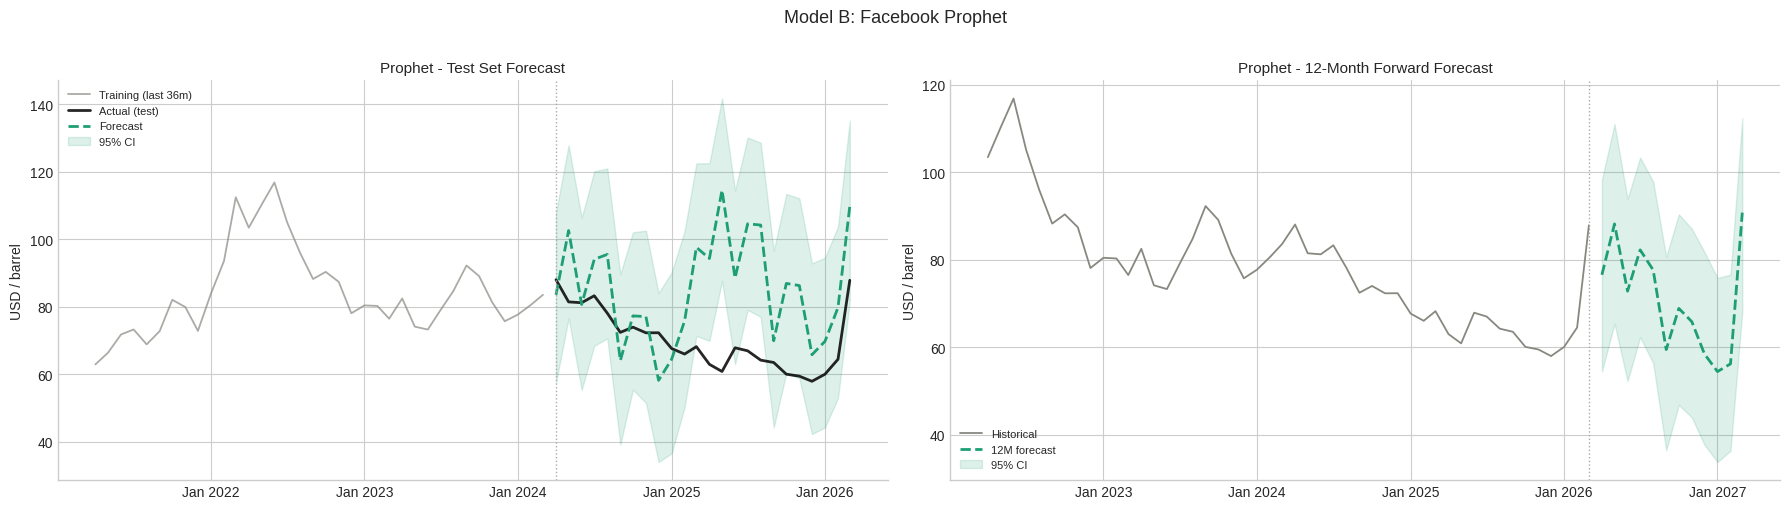

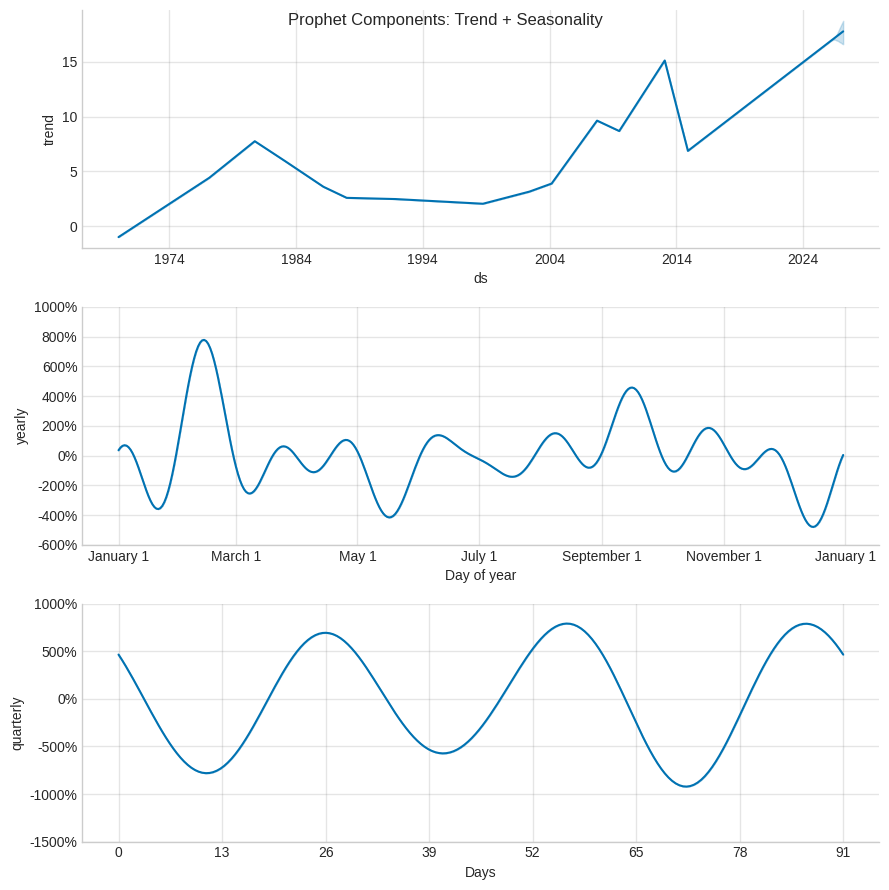

Prophet model saved.


In [10]:
# Refit on full series for the forward forecast
full_prophet_df = pd.DataFrame({'ds': series.index, 'y': series.values})
prophet_full = Prophet(
    changepoint_prior_scale=0.15,
    seasonality_prior_scale=10,
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95
)
prophet_full.add_seasonality(name='quarterly', period=91.25, fourier_order=5)
prophet_full.fit(full_prophet_df)

future_full = prophet_full.make_future_dataframe(periods=FORECAST_MONTHS, freq='MS')
fc_full     = prophet_full.predict(future_full)
prophet_fwd = fc_full.tail(FORECAST_MONTHS)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
prophet_future    = pd.Series(prophet_fwd['yhat'].values,      index=future_dates)
prophet_future_lo = pd.Series(prophet_fwd['yhat_lower'].values, index=future_dates)
prophet_future_hi = pd.Series(prophet_fwd['yhat_upper'].values, index=future_dates)
all_futures['Prophet'] = prophet_future

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

plot_forecast(axes[0], train, test, prophet_preds,
              prophet_ci_lo, prophet_ci_hi, C_TEAL,
              'Prophet - Test Set Forecast')

ax2 = axes[1]
ax2.plot(series.index[-48:], series.values[-48:], color=C_GRAY, lw=1.3, label='Historical')
ax2.plot(prophet_future.index, prophet_future.values,
         color=C_TEAL, lw=2, ls='--', label='12M forecast')
ax2.fill_between(prophet_future.index, prophet_future_lo, prophet_future_hi,
                 alpha=0.15, color=C_TEAL, label='95% CI')
ax2.axvline(series.index[-1], color='#aaa', lw=1, ls=':')
ax2.set_title('Prophet - 12-Month Forward Forecast', fontsize=11, fontweight='medium')
ax2.set_ylabel('USD / barrel', fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.legend(fontsize=8)

plt.suptitle('Model B: Facebook Prophet', fontsize=13, fontweight='medium', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '03_prophet_results.png'), dpi=150, bbox_inches='tight')
plt.show()

# Prophet components plot
fig2 = prophet_full.plot_components(fc_full)
fig2.suptitle('Prophet Components: Trend + Seasonality', fontsize=12, fontweight='medium')
fig2.savefig(os.path.join(PATHS['figures'], '03_prophet_components.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save model
with open(os.path.join(PATHS['models'], 'prophet_model.pkl'), 'wb') as f:
    pickle.dump(prophet_full, f)
print('Prophet model saved.')

---
## 4 - Model C: LSTM

### Why LSTM?
Long Short-Term Memory networks can learn **non-linear temporal dependencies** that
classical models miss - particularly the asymmetric recovery patterns after shocks
that we quantified in Notebook 02.

### Architecture
- **Input:** sliding window of the last `LOOK_BACK` months of prices (scaled 0-1)
- **Layers:** LSTM(64) -> Dropout(0.2) -> LSTM(32) -> Dropout(0.2) -> Dense(1)
- **Training:** EarlyStopping on validation loss, ModelCheckpoint to Drive
- **Walk-forward:** after training, we re-predict each test step using the actual
  prior values (not the model's own predictions) to match how ARIMA was evaluated

In [11]:
LOOK_BACK   = 24    # months of history fed into each LSTM input window
BATCH_SIZE  = 16
EPOCHS      = 150
VAL_SPLIT   = 0.15  # fraction of training data held for validation during training

# Scale the full price series to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_all   = scaler.fit_transform(series.values.reshape(-1, 1)).flatten()
scaled_train = scaled_all[:len(train)]
scaled_full  = scaled_all  # used for walk-forward prediction on test set

def make_sequences(data, look_back):
    """Convert a 1D array into overlapping (X, y) pairs."""
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i : i + look_back])
        y.append(data[i + look_back])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(scaled_train, LOOK_BACK)
# Reshape for LSTM: (samples, time_steps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

print(f'Training sequences : X={X_train.shape}  y={y_train.shape}')
print(f'Look-back window   : {LOOK_BACK} months')
print(f'Effective train start: month index {LOOK_BACK} = {train.index[LOOK_BACK].date()}')

Training sequences : X=(627, 24, 1)  y=(627,)
Look-back window   : 24 months
Effective train start: month index 24 = 1972-01-01


In [12]:
def build_lstm(look_back):
    model = Sequential([
        LSTM(64, return_sequences=True,
             input_shape=(look_back, 1),
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        Dropout(0.2),
        LSTM(32, return_sequences=False,
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='huber'     # more robust than MSE for outliers / oil price spikes
    )
    return model

lstm_model = build_lstm(LOOK_BACK)
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
checkpoint_path = os.path.join(PATHS['models'], 'lstm_best.keras')

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print('Training LSTM...')
print(f'  Max epochs : {EPOCHS}  (early stopping patience=20)')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Val split  : {VAL_SPLIT} ({int(len(X_train) * VAL_SPLIT)} sequences)')
print()

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=callbacks,
    shuffle=False,      # preserve temporal order
    verbose=1
)

best_epoch = np.argmin(history_lstm.history['val_loss']) + 1
print(f'\nTraining complete. Best epoch: {best_epoch}')
print(f'Best val_loss: {min(history_lstm.history["val_loss"]):.6f}')

Training LSTM...
  Max epochs : 150  (early stopping patience=20)
  Batch size : 16
  Val split  : 0.15 (94 sequences)

Epoch 1/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0201 - val_loss: 0.0164
Epoch 2/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0143 - val_loss: 0.0113
Epoch 3/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0113 - val_loss: 0.0089
Epoch 4/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0072 - val_loss: 0.0072
Epoch 5/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0068 - val_loss: 0.0067
Epoch 6/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0060 - val_loss: 0.0066
Epoch 7/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0058 - val_loss: 0.0063
Epoch 8/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0059 - val_loss: 0.0055
Epoch 9/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0058 - val_loss: 0.0060
Epoch 10/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0051 - val_loss: 0.0063
Epoch 11/150
34/34 ━━

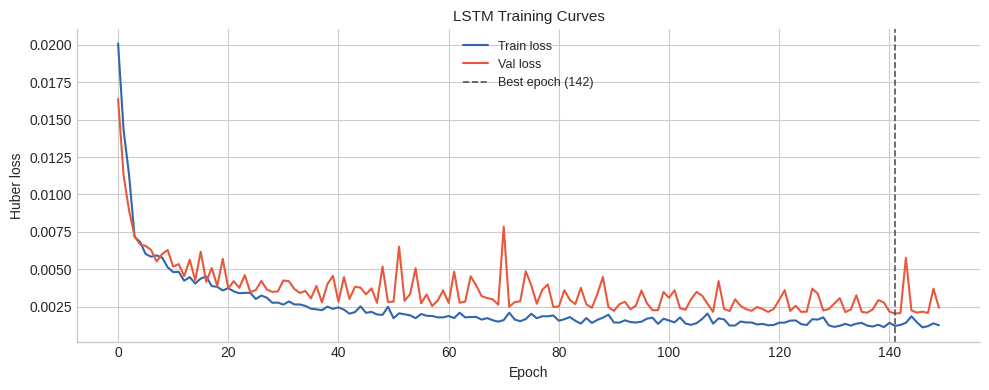

In [14]:
# Plot training and validation loss curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_lstm.history['loss'],     color=C_BLUE,  lw=1.5, label='Train loss')
ax.plot(history_lstm.history['val_loss'], color=C_RED,   lw=1.5, label='Val loss')
ax.axvline(best_epoch - 1, color='#555', lw=1.2, ls='--',
           label=f'Best epoch ({best_epoch})')
ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('Huber loss', fontsize=10)
ax.set_title('LSTM Training Curves', fontsize=11, fontweight='medium')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '03_lstm_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Walk-forward prediction on test set
# At each step, the input window uses the actual prices (not predictions)
# to match the evaluation protocol used for ARIMA

print('Running LSTM walk-forward prediction on test set...')
lstm_preds = []

train_end_idx = len(train)  # index in scaled_full where test starts

for i in range(TEST_MONTHS):
    # Window of LOOK_BACK actual scaled values ending just before this test step
    window_start = train_end_idx + i - LOOK_BACK
    window_end   = train_end_idx + i
    window = scaled_full[window_start:window_end]
    X_input = window.reshape(1, LOOK_BACK, 1)
    pred_scaled = lstm_model.predict(X_input, verbose=0)[0][0]
    pred_price  = scaler.inverse_transform([[pred_scaled]])[0][0]
    lstm_preds.append(pred_price)

lstm_preds = np.array(lstm_preds)

print('LSTM test-set evaluation:')
m = evaluate(test.values, lstm_preds, 'LSTM (walk-forward)')
all_metrics.append(m)
all_preds['LSTM'] = pd.Series(lstm_preds, index=test.index)

Running LSTM walk-forward prediction on test set...
LSTM test-set evaluation:
  LSTM (walk-forward)
    RMSE : 6.7405
    MAE  : 4.6610
    MAPE : 6.40%



Generating LSTM 12-month forward forecast (auto-regressive)...
  Forecast range: $76.24 - $84.91


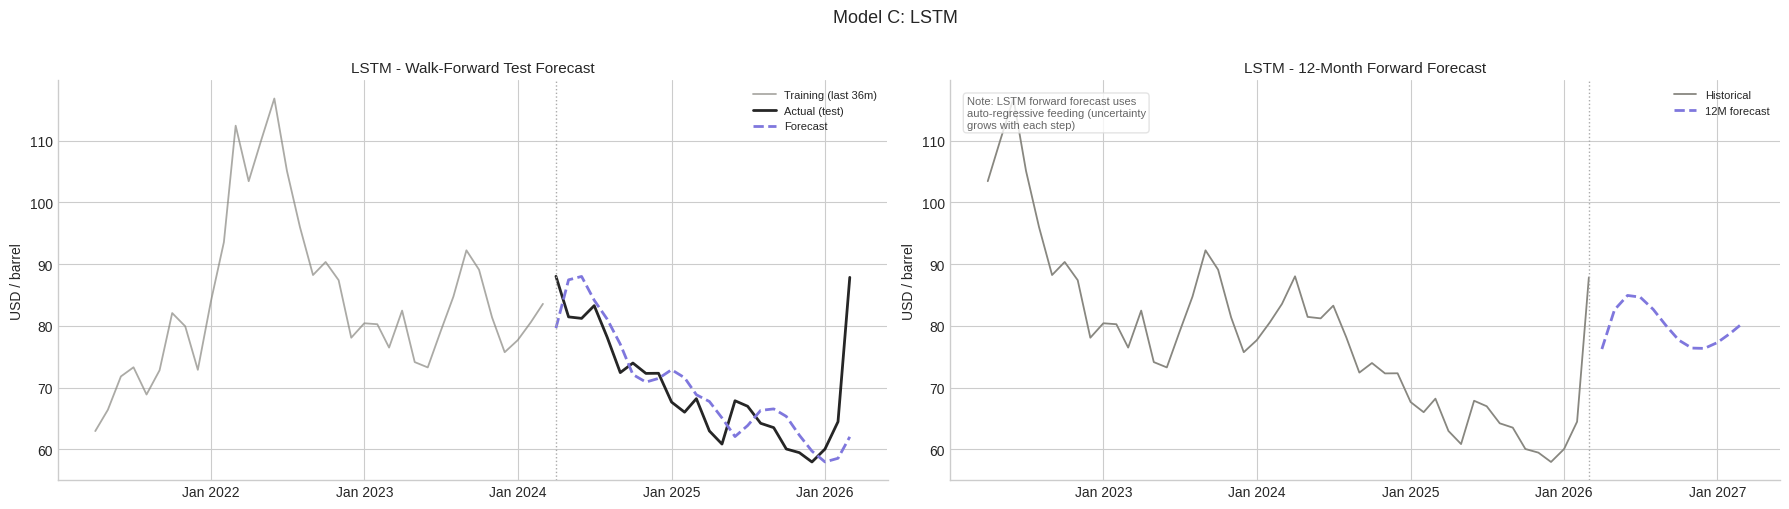

LSTM model and scaler saved.


In [16]:
# 12-month forward forecast: auto-regressive (each prediction feeds the next window)
print('Generating LSTM 12-month forward forecast (auto-regressive)...')

lstm_future_preds = []
# Start from the last LOOK_BACK actual values
input_seq = scaled_full[-LOOK_BACK:].tolist()

for step in range(FORECAST_MONTHS):
    X_input = np.array(input_seq[-LOOK_BACK:]).reshape(1, LOOK_BACK, 1)
    pred_scaled = lstm_model.predict(X_input, verbose=0)[0][0]
    lstm_future_preds.append(pred_scaled)
    input_seq.append(pred_scaled)   # feed prediction back into the window

# Inverse-transform back to USD/bbl
lstm_future_prices = scaler.inverse_transform(
    np.array(lstm_future_preds).reshape(-1, 1)
).flatten()

lstm_future = pd.Series(lstm_future_prices, index=future_dates)
all_futures['LSTM'] = lstm_future

print(f'  Forecast range: ${lstm_future.min():.2f} - ${lstm_future.max():.2f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

plot_forecast(axes[0], train, test, lstm_preds,
              color=C_PURPLE, title='LSTM - Walk-Forward Test Forecast')

ax2 = axes[1]
ax2.plot(series.index[-48:], series.values[-48:], color=C_GRAY, lw=1.3, label='Historical')
ax2.plot(lstm_future.index, lstm_future.values,
         color=C_PURPLE, lw=2, ls='--', label='12M forecast')
ax2.axvline(series.index[-1], color='#aaa', lw=1, ls=':')
ax2.set_title('LSTM - 12-Month Forward Forecast', fontsize=11, fontweight='medium')
ax2.set_ylabel('USD / barrel', fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.legend(fontsize=8)
ax2.text(0.02, 0.96, 'Note: LSTM forward forecast uses\nauto-regressive feeding (uncertainty\ngrows with each step)',
         transform=ax2.transAxes, fontsize=8, va='top', color='#666',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#ddd', alpha=0.8))

plt.suptitle('Model C: LSTM', fontsize=13, fontweight='medium', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '03_lstm_results.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save LSTM model and scaler
lstm_model.save(os.path.join(PATHS['models'], 'lstm_final.keras'))
with open(os.path.join(PATHS['models'], 'lstm_scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print('LSTM model and scaler saved.')

---
## 5 - Model Comparison

All three models evaluated on the identical 24-month test set.

In [17]:
compare_df = pd.DataFrame(all_metrics).set_index('model')
compare_df['Rank (RMSE)'] = compare_df['RMSE'].rank().astype(int)

print('=' * 60)
print('  MODEL COMPARISON - 24-month test set')
print('=' * 60)
print(compare_df.to_string())
print()
best_rmse  = compare_df['RMSE'].idxmin()
best_mape  = compare_df['MAPE'].idxmin()
print(f'  Best RMSE  : {best_rmse}  ({compare_df.loc[best_rmse, "RMSE"]:.4f})')
print(f'  Best MAPE  : {best_mape}  ({compare_df.loc[best_mape, "MAPE"]:.2f}%)')
print()
print('Metric definitions:')
print('  RMSE - Root Mean Squared Error (penalises large errors; same unit as price)')
print('  MAE  - Mean Absolute Error (average absolute deviation in USD/bbl)')
print('  MAPE - Mean Absolute Percentage Error (scale-independent, % of actual price)')

  MODEL COMPARISON - 24-month test set
                                  RMSE      MAE   MAPE  Rank (RMSE)
model                                                              
ARIMA (walk-forward)            5.7498   3.8816   5.28            1
Prophet (custom changepoints)  22.1845  17.7257  26.54            3
LSTM (walk-forward)             6.7405   4.6610   6.40            2

  Best RMSE  : ARIMA (walk-forward)  (5.7498)
  Best MAPE  : ARIMA (walk-forward)  (5.28%)

Metric definitions:
  RMSE - Root Mean Squared Error (penalises large errors; same unit as price)
  MAE  - Mean Absolute Error (average absolute deviation in USD/bbl)
  MAPE - Mean Absolute Percentage Error (scale-independent, % of actual price)


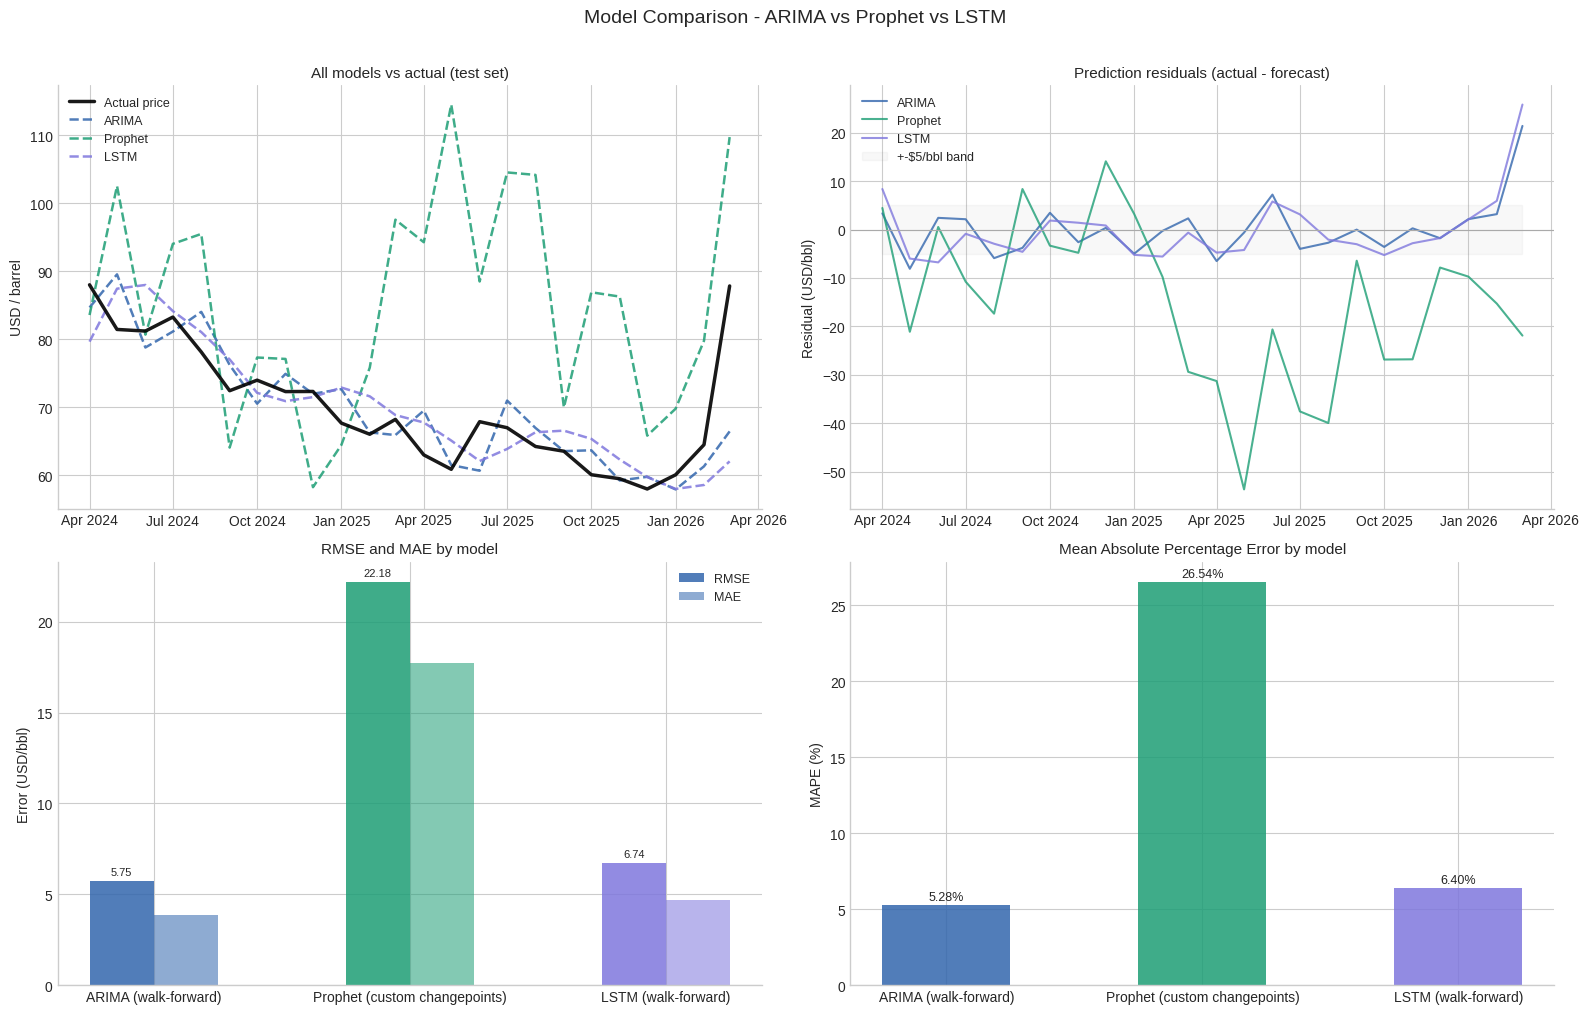

In [19]:
model_colors = {'ARIMA': C_BLUE, 'Prophet': C_TEAL, 'LSTM': C_PURPLE}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Panel 1: Actual vs all predictions on test set ────────────────────────
ax = axes[0][0]
ax.plot(test.index, test.values, color='black', lw=2.5, alpha=0.9,
        label='Actual price', zorder=5)
for mname, pred_series in all_preds.items():
    ax.plot(pred_series.index, pred_series.values,
            color=model_colors[mname.split(' ')[0]], lw=1.8, ls='--', # Corrected line
            alpha=0.85, label=mname)
ax.set_title('All models vs actual (test set)', fontsize=11, fontweight='medium')
ax.set_ylabel('USD / barrel', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=9)

# ── Panel 2: Residuals (prediction errors) ────────────────────────────────
ax = axes[0][1]
for mname, pred_series in all_preds.items():
    residuals = test.values - pred_series.values
    ax.plot(test.index, residuals,
            color=model_colors[mname.split(' ')[0]], lw=1.5, alpha=0.8, label=mname) # Corrected line
ax.axhline(0, color='#aaa', lw=0.8)
ax.fill_between(test.index, -5, 5, alpha=0.05, color='gray', label='+-$5/bbl band')
ax.set_title('Prediction residuals (actual - forecast)', fontsize=11, fontweight='medium')
ax.set_ylabel('Residual (USD/bbl)', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=9)

# ── Panel 3: Metric bar chart ─────────────────────────────────────────────
ax = axes[1][0]
x = np.arange(len(compare_df))
w = 0.25
bars_rmse = ax.bar(x - w, compare_df['RMSE'],  w, label='RMSE',
                   color=[model_colors[m.split(' ')[0]] for m in compare_df.index], alpha=0.85) # Corrected line
bars_mae  = ax.bar(x,     compare_df['MAE'],   w, label='MAE',
                   color=[model_colors[m.split(' ')[0]] for m in compare_df.index], alpha=0.55) # Corrected line
ax.set_xticks(x - w/2)
ax.set_xticklabels(compare_df.index, fontsize=10)
ax.set_ylabel('Error (USD/bbl)', fontsize=10)
ax.set_title('RMSE and MAE by model', fontsize=11, fontweight='medium')
ax.legend(fontsize=9)
for bar in bars_rmse:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

# ── Panel 4: MAPE bar chart ───────────────────────────────────────────────
ax = axes[1][1]
bars_mape = ax.bar(compare_df.index, compare_df['MAPE'],
                   color=[model_colors[m.split(' ')[0]] for m in compare_df.index],
                   alpha=0.85, width=0.5) # Corrected line
ax.set_ylabel('MAPE (%)', fontsize=10)
ax.set_title('Mean Absolute Percentage Error by model', fontsize=11, fontweight='medium')
for bar, val in zip(bars_mape, compare_df['MAPE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison - ARIMA vs Prophet vs LSTM', fontsize=14, fontweight='medium', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '03_model_comparison.png'), dpi=160, bbox_inches='tight')
plt.show()

---
## 6 - Combined 12-Month Forward Forecast

All three models projected 12 months beyond the last data point,
shown alongside the most recent 36 months of actual data for context.

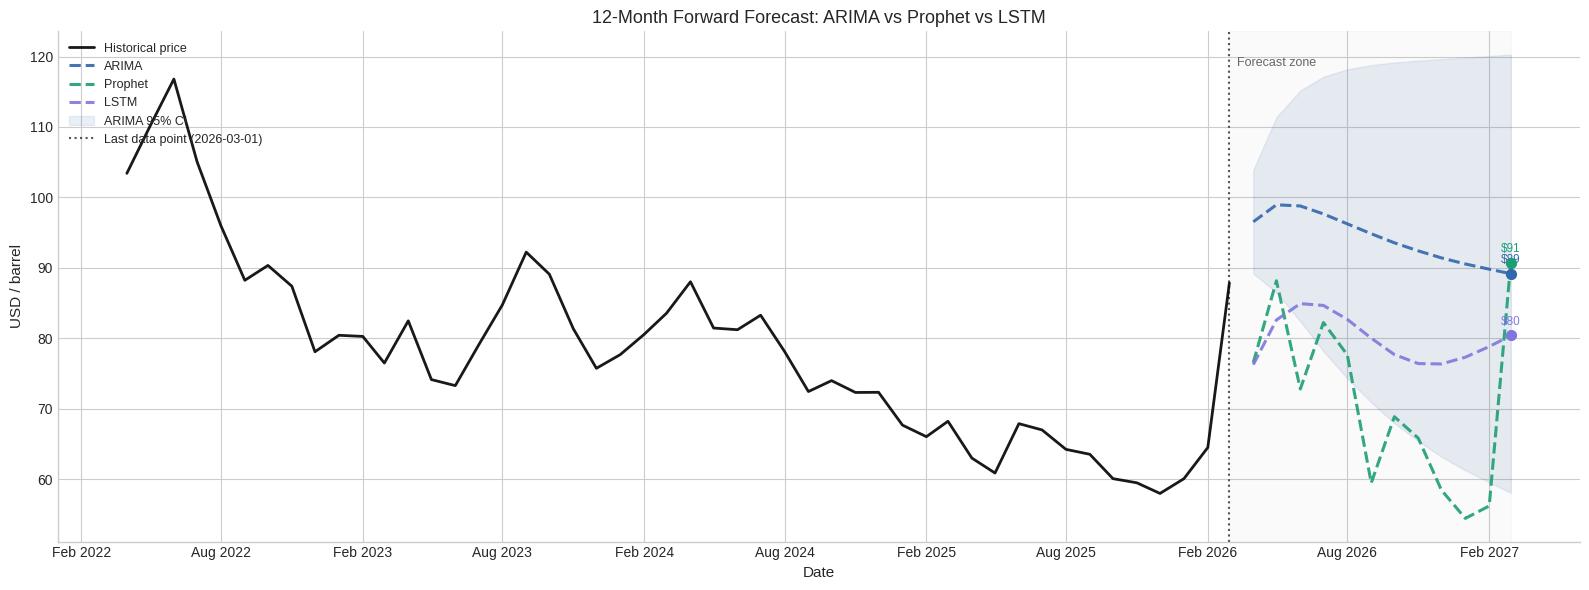

12-Month Forward Forecast Summary (USD/barrel):
-------------------------------------------------------
         ARIMA  Prophet       LSTM
2026-04  96.53    76.52  76.239998
2026-05  98.94    88.15  82.589996
2026-06  98.77    72.78  84.910004
2026-07  97.64    82.22  84.650002
2026-08  96.23    77.62  82.669998
2026-09  94.83    59.43  80.000000
2026-10  93.54    68.85  77.669998
2026-11  92.40    65.80  76.389999
2026-12  91.40    58.43  76.339996
2027-01  90.54    54.41  77.290001
2027-02  89.80    56.17  78.800003
2027-03  89.16    90.72  80.379997


In [20]:
fig, ax = plt.subplots(figsize=(16, 6))

# Historical context: last 48 months
recent = series.iloc[-48:]
ax.plot(recent.index, recent.values, color='black', lw=2, alpha=0.9,
        label='Historical price', zorder=5)

# Each model's forward forecast
for mname, fwd in all_futures.items():
    ax.plot(fwd.index, fwd.values,
            color=model_colors[mname], lw=2.2, ls='--',
            alpha=0.9, label=mname)
    # End-point label
    ax.scatter([fwd.index[-1]], [fwd.values[-1]],
               color=model_colors[mname], s=50, zorder=6)
    ax.text(fwd.index[-1], fwd.values[-1] + 1.5,
            f'${fwd.values[-1]:.0f}', fontsize=8.5,
            color=model_colors[mname], ha='center')

# ARIMA confidence band (widest of the three)
ax.fill_between(arima_future.index, arima_future_lo, arima_future_hi,
                alpha=0.10, color=C_BLUE, label='ARIMA 95% CI')

ax.axvline(series.index[-1], color='#555', lw=1.5, ls=':',
           label=f'Last data point ({series.index[-1].date()})')
ax.axvspan(series.index[-1], future_dates[-1], alpha=0.04, color='gray')
ax.text(series.index[-1] + pd.DateOffset(days=10),
        ax.get_ylim()[1] * 0.97, 'Forecast zone',
        fontsize=9, color='#666', va='top')

ax.set_title('12-Month Forward Forecast: ARIMA vs Prophet vs LSTM',
             fontsize=13, fontweight='medium')
ax.set_ylabel('USD / barrel', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '03_combined_forecast.png'), dpi=160, bbox_inches='tight')
plt.show()

# Summary table
print('12-Month Forward Forecast Summary (USD/barrel):')
print('-' * 55)
forecast_summary = pd.DataFrame({
    'ARIMA':   arima_future.values,
    'Prophet': prophet_future.values,
    'LSTM':    lstm_future.values,
}, index=future_dates)
forecast_summary.index = forecast_summary.index.strftime('%Y-%m')
print(forecast_summary.round(2).to_string())

---
## 7 - Save All Outputs to Drive

In [21]:
# ── Save forecast CSVs ─────────────────────────────────────────────────────
test_preds_df = pd.DataFrame(
    {m: s.values for m, s in all_preds.items()},
    index=test.index
)
test_preds_df['actual'] = test.values
test_preds_path = os.path.join(PATHS['forecasts'], 'test_predictions.csv')
test_preds_df.to_csv(test_preds_path)
print(f'Saved test predictions  -> {test_preds_path}')

future_preds_df = pd.DataFrame(
    {m: s.values for m, s in all_futures.items()},
    index=future_dates
)
future_preds_path = os.path.join(PATHS['forecasts'], 'forward_forecast_12m.csv')
future_preds_df.to_csv(future_preds_path)
print(f'Saved forward forecast  -> {future_preds_path}')

# ── Save evaluation metrics ────────────────────────────────────────────────
metrics_path = os.path.join(PATHS['forecasts'], 'model_evaluation_metrics.csv')
compare_df.to_csv(metrics_path)
print(f'Saved evaluation metrics -> {metrics_path}')

# ── Save metadata for Streamlit dashboard ─────────────────────────────────
forecast_meta = {
    'last_data_date':  str(series.index[-1].date()),
    'forecast_start':  str(future_dates[0].date()),
    'forecast_end':    str(future_dates[-1].date()),
    'test_months':     TEST_MONTHS,
    'look_back':       LOOK_BACK,
    'arima_order':     str(final_arima.order),
    'arima_seasonal':  str(final_arima.seasonal_order),
    'metrics':         compare_df.to_dict()
}
meta_path = os.path.join(PATHS['root'], 'forecast_meta.json')
with open(meta_path, 'w') as f:
    json.dump(forecast_meta, f, indent=2)
print(f'Saved forecast metadata  -> {meta_path}')

# ── Print full summary ─────────────────────────────────────────────────────
print()
print('=' * 60)
print('  FORECASTING NOTEBOOK COMPLETE')
print('=' * 60)
print()
print('  Models trained and saved:')
print('    models/arima_model.pkl')
print('    models/prophet_model.pkl')
print('    models/lstm_final.keras')
print('    models/lstm_scaler.pkl')
print()
print('  Evaluation results (24-month test):')
print(compare_df[['RMSE', 'MAE', 'MAPE']].to_string())
print()
print(f'  Best model by RMSE : {compare_df["RMSE"].idxmin()}')
print(f'  Best model by MAPE : {compare_df["MAPE"].idxmin()}')
print()
print('  12-month forward forecast endpoint (USD/bbl):')
for mname, fwd in all_futures.items():
    print(f'    {mname:<10}: ${fwd.values[-1]:.2f}  ({future_dates[-1].date()})')
print()
print('  Next: Open 04_dashboard.py to build the Streamlit app.')

Saved test predictions  -> /content/drive/MyDrive/crude_oil_project/outputs/forecasts/test_predictions.csv
Saved forward forecast  -> /content/drive/MyDrive/crude_oil_project/outputs/forecasts/forward_forecast_12m.csv
Saved evaluation metrics -> /content/drive/MyDrive/crude_oil_project/outputs/forecasts/model_evaluation_metrics.csv
Saved forecast metadata  -> /content/drive/MyDrive/crude_oil_project/forecast_meta.json

  FORECASTING NOTEBOOK COMPLETE

  Models trained and saved:
    models/arima_model.pkl
    models/prophet_model.pkl
    models/lstm_final.keras
    models/lstm_scaler.pkl

  Evaluation results (24-month test):
                                  RMSE      MAE   MAPE
model                                                 
ARIMA (walk-forward)            5.7498   3.8816   5.28
Prophet (custom changepoints)  22.1845  17.7257  26.54
LSTM (walk-forward)             6.7405   4.6610   6.40

  Best model by RMSE : ARIMA (walk-forward)
  Best model by MAPE : ARIMA (walk-forward)

 

---
## Figures and Files Saved This Notebook

| File | Description |
|---|---|
| `outputs/figures/03_train_test_split.png` | Train/test split visualisation |
| `outputs/figures/03_arima_results.png` | ARIMA walk-forward + 12M forecast |
| `outputs/figures/03_prophet_results.png` | Prophet test + 12M forecast |
| `outputs/figures/03_prophet_components.png` | Prophet trend/seasonality decomposition |
| `outputs/figures/03_lstm_training_curves.png` | LSTM loss curves |
| `outputs/figures/03_lstm_results.png` | LSTM test + 12M forecast |
| `outputs/figures/03_model_comparison.png` | Residuals + RMSE/MAE/MAPE comparison grid |
| `outputs/figures/03_combined_forecast.png` | All three forecasts on one chart |
| `models/arima_model.pkl` | Fitted final ARIMA |
| `models/prophet_model.pkl` | Fitted final Prophet |
| `models/lstm_final.keras` | Trained LSTM weights |
| `models/lstm_scaler.pkl` | MinMaxScaler fitted on training data |
| `outputs/forecasts/test_predictions.csv` | All model predictions on the test set |
| `outputs/forecasts/forward_forecast_12m.csv` | 12-month forward forecast table |
| `outputs/forecasts/model_evaluation_metrics.csv` | RMSE / MAE / MAPE table |
| `forecast_meta.json` | Model parameters + metrics (used by Streamlit dashboard) |

**Next:** Open `04_dashboard.py` to build the Streamlit app that wraps all of this.